## Q2

Prepare input and output

In [16]:
import torch
import random
import numpy as np

data= np.load('./Marmousi2_5hz_Data.npy')
# Small value to prevent division by zero in SNR
epsilon = 1e-10

# Example data with shape (30, 1000, 200)
dat = torch.tensor(data.reshape(30,1000,200))  # Convert to tensor
num_shots = dat.shape[0]
shots_per_noise_level = 10

# Define different levels of noise (standard deviations)
noise_levels = torch.linspace(0.5, 1, shots_per_noise_level)

# Initialize a list to collect shots with noise and SNR
noisy_shots = []
clean_shots = []
snr_values = []

# Maximum percentage of gaps
max_gap_percentage = 0.2

# Add Gaussian noise to each shot and calculate SNR
for i in range(num_shots):
    for noise_level in noise_levels:
        noise = torch.normal(mean=0.0, std=noise_level, size=dat[i, :, :].shape)
        clean_shot = dat[i, :, :]
        noisy_shot = dat[i, :, :] + noise
        
        # Create random gaps in the noisy shot
        mask_size = noisy_shot.shape[1]  # Assuming size corresponds to 1000 in (30, 1000, 200)
        num_gaps = int(mask_size * max_gap_percentage)
        gap_indices = random.sample(range(mask_size), num_gaps)  # Randomly choose indices to mask

        # Apply the gaps to the noisy shot
        for idx in gap_indices:
            noisy_shot[:, idx] = 0  # Set to zero or any value to create a gap

        # Calculate SNR
        signal_power = torch.mean(dat[i, :, :]**2)  # Power of the signal
        noise_power = torch.mean(noise**2) + epsilon  # Power of the noise with epsilon
        snr = 10 * torch.log10(signal_power / noise_power)  # SNR in dB   

        snr_values.append(snr.item())
        noisy_shots.append(noisy_shot)
        clean_shots.append(clean_shot)

# Convert list to a PyTorch tensor
data_noisy = torch.stack(noisy_shots)
data_clean = torch.stack(clean_shots)

# Check the shape and SNR values
print('The number of noisy data:', data_noisy.shape)  # Shape of the noisy data
print(snr_values[0:10])  # Print the SNR for each noisy shot

The number of noisy data: torch.Size([300, 1000, 200])
[11.717195510864258, 10.825191497802734, 9.995020866394043, 9.238245010375977, 8.564042091369629, 7.902656078338623, 7.271003723144531, 6.737056255340576, 6.197735786437988, 5.711652755737305]


Divide the data into 80% for training and 20% for testing.

In [17]:
from sklearn.model_selection import train_test_split

# We generated 30 shots x 10 noise levels = 300 samples
# data_noisy/data_clean: (N, T, R) = (300, 1000, 200)
X = data_noisy.float()
Y = data_clean.float()

# 80/20 split
idx_all = np.arange(X.shape[0])
idx_train, idx_test = train_test_split(idx_all, test_size=0.2, random_state=42, shuffle=True)

X_train, Y_train = X[idx_train], Y[idx_train]
X_test, Y_test = X[idx_test], Y[idx_test]

print("Train shapes:", X_train.shape, Y_train.shape)
print("Test shapes:", X_test.shape, Y_test.shape)

Train shapes: torch.Size([240, 1000, 200]) torch.Size([240, 1000, 200])
Test shapes: torch.Size([60, 1000, 200]) torch.Size([60, 1000, 200])


Plot the input and target of your problem to fully understand what you are trying to accomplish.

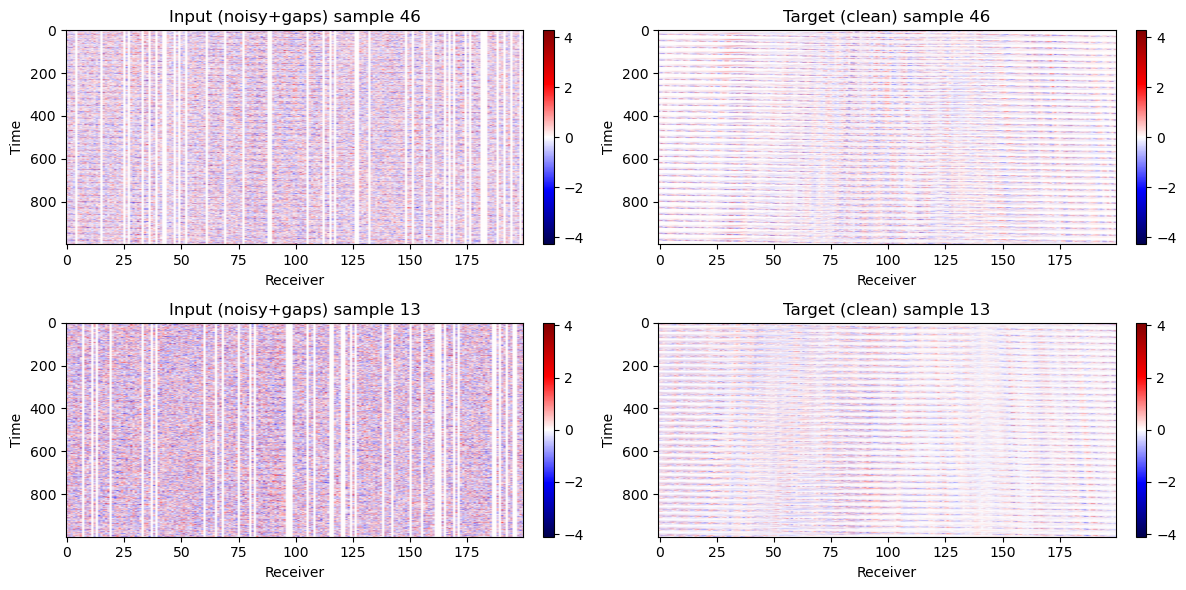

In [18]:
import matplotlib.pyplot as plt

# Plot reproducible examples: input (noisy+gaps) vs target (clean)
# These sample IDs come from the previously displayed figure titles.
example_ids = [46, 13]
num_examples = len(example_ids)

plt.figure(figsize=(12, 6))
for i, eid in enumerate(example_ids):
    inp = X_train[eid].numpy()   # (T, R)
    tgt = Y_train[eid].numpy()   # (T, R)

    # Use a shared symmetric color scale so input and target are directly comparable.
    vmax = max(np.abs(inp).max(), np.abs(tgt).max())
    vmin = -vmax

    plt.subplot(num_examples, 2, 2*i + 1)
    im1 = plt.imshow(inp, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
    plt.title(f"Input (noisy+gaps) sample {eid}")
    plt.xlabel("Receiver")
    plt.ylabel("Time")
    plt.colorbar(im1, fraction=0.046, pad=0.04)

    plt.subplot(num_examples, 2, 2*i + 2)
    im2 = plt.imshow(tgt, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
    plt.title(f"Target (clean) sample {eid}")
    plt.xlabel("Receiver")
    plt.ylabel("Time")
    plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Design a U-Net to denoise and interpolate the seismic data simultaneously.

In [19]:
import random
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Training seed for reproducibility.
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
loader_generator = torch.Generator().manual_seed(seed)

# Dataset / DataLoader
# Model expects (B, C, H, W). Here H=time(1000), W=receivers(200), C=1
train_ds = TensorDataset(X_train.unsqueeze(1), Y_train.unsqueeze(1))
test_ds = TensorDataset(X_test.unsqueeze(1), Y_test.unsqueeze(1))

batch_size = 4
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=loader_generator)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("One batch shapes:", next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape)

One batch shapes: torch.Size([4, 1, 1000, 200]) torch.Size([4, 1, 1000, 200])


In [20]:
from q2_unet_denoise import UNet2D, get_device

device = get_device()
model = UNet2D(in_channels=1, out_channels=1, base=16).to(device)

print("Device:", device)
print(model)

Device: cuda
UNet2D(
  (enc1): DoubleConv(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): DoubleConv(
    (net): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
    )
  )
  (pool2): MaxPool2d(kernel_size=2, stri

In [21]:
from q2_unet_denoise import train_unet2d

history = train_unet2d(
    model,
    train_loader,
    test_loader,
    device=device,
    epochs=20,
    lr=1e-3,
)

for i, (tr, te) in enumerate(zip(history.train_mse, history.test_mse), start=1):
    print(f"Epoch {i:02d} | train MSE: {tr:.6f} | test MSE: {te:.6f}")

model_path = "best_unet2d_q2.pt"
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "in_channels": 1,
        "out_channels": 1,
        "base": 16,
        "train_mse": history.train_mse,
        "test_mse": history.test_mse,
    },
    model_path,
)
print(f"Saved model to {model_path}")

Epoch 01 | train MSE: 0.309565 | test MSE: 0.154191
Epoch 02 | train MSE: 0.201407 | test MSE: 0.152998
Epoch 03 | train MSE: 0.160712 | test MSE: 0.143801
Epoch 04 | train MSE: 0.167492 | test MSE: 0.131518
Epoch 05 | train MSE: 0.135538 | test MSE: 0.159026
Epoch 06 | train MSE: 0.128582 | test MSE: 0.126932
Epoch 07 | train MSE: 0.140346 | test MSE: 0.127691
Epoch 08 | train MSE: 0.138808 | test MSE: 0.185038
Epoch 09 | train MSE: 0.119467 | test MSE: 0.133806
Epoch 10 | train MSE: 0.108226 | test MSE: 0.133912
Epoch 11 | train MSE: 0.105581 | test MSE: 0.140658
Epoch 12 | train MSE: 0.108681 | test MSE: 0.125190
Epoch 13 | train MSE: 0.107168 | test MSE: 0.124615
Epoch 14 | train MSE: 0.102041 | test MSE: 0.147595
Epoch 15 | train MSE: 0.097680 | test MSE: 0.154663
Epoch 16 | train MSE: 0.098157 | test MSE: 0.136582
Epoch 17 | train MSE: 0.115573 | test MSE: 0.148376
Epoch 18 | train MSE: 0.115175 | test MSE: 0.134454
Epoch 19 | train MSE: 0.099749 | test MSE: 0.125647
Epoch 20 | t

In [23]:
# Reload the saved model after a kernel restart if needed.
checkpoint = torch.load(model_path, map_location=device)
model = UNet2D(
    in_channels=checkpoint.get("in_channels", 1),
    out_channels=checkpoint.get("out_channels", 1),
    base=checkpoint.get("base", 16),
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print(f"Loaded model from {model_path}")

Loaded model from best_unet2d_q2.pt


C:\Users\wkkong\AppData\Local\Temp\ipykernel_20812\599554410.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Plot some samples of the test set, obtain the SNR for each test sample, and calculate the SNR improvement after applying the U-Net.

Sample IDs: [39  5 45]


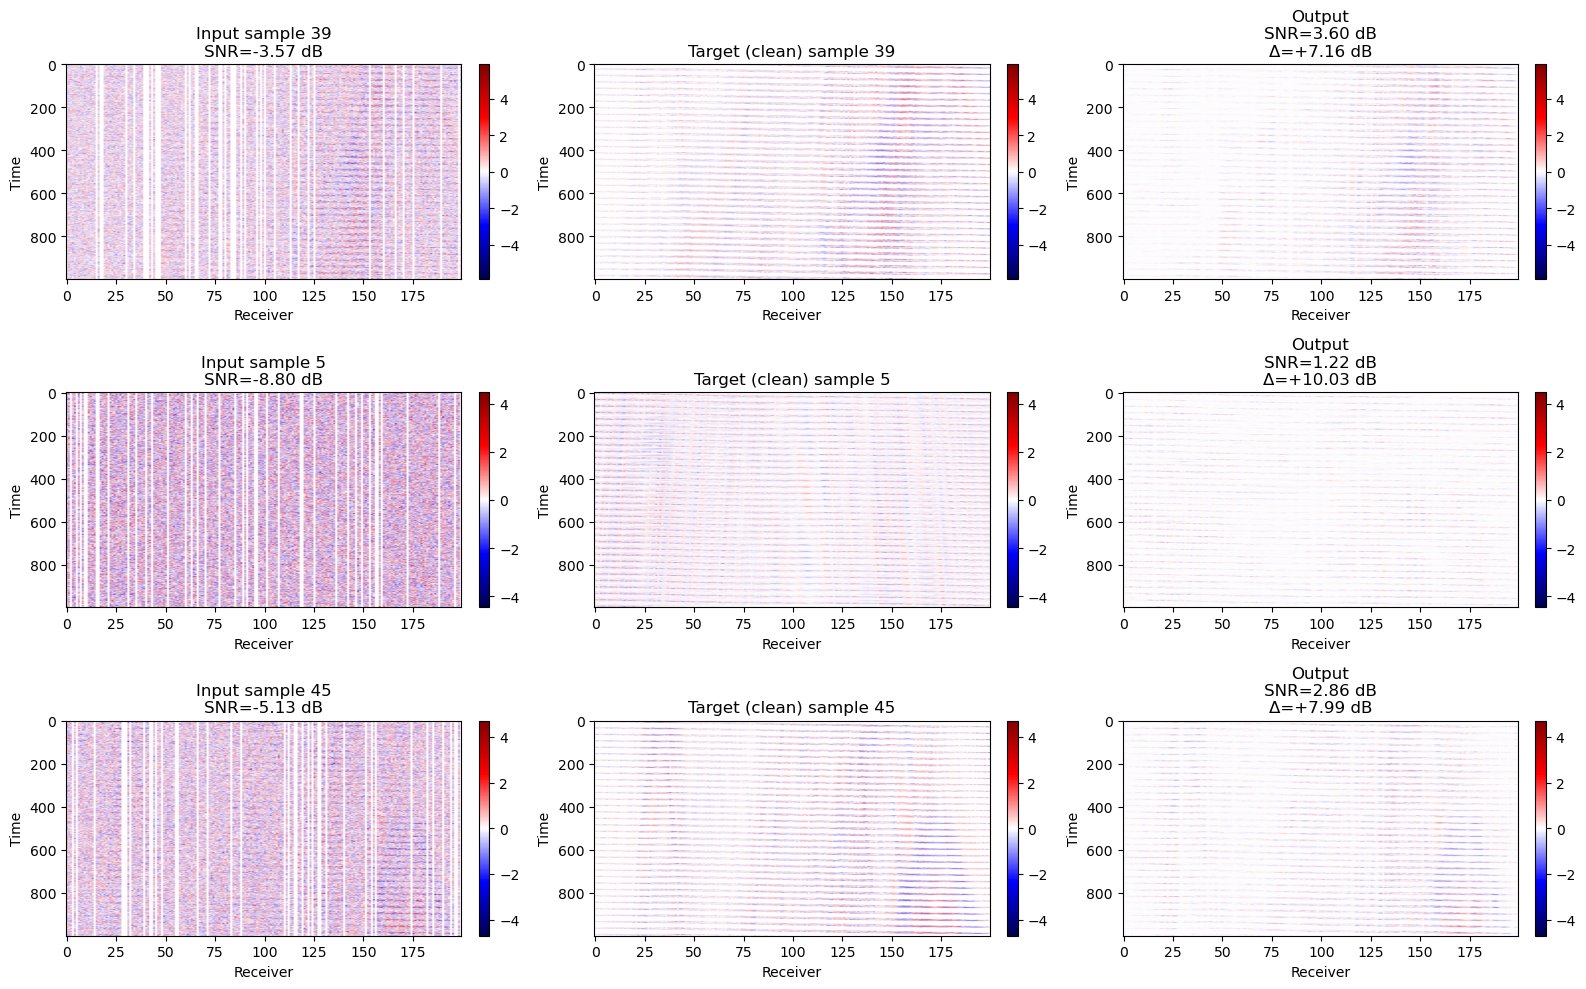

Per-sample SNR (input): [-3.56712246 -8.80361938 -5.13219452]
Per-sample SNR (output): [3.59543657 1.22314811 2.85709381]
SNR improvement (output - input): [ 7.16255903 10.02676749  7.98928833]
Mean SNR improvement: 8.392871618270874 dB


In [24]:
from q2_unet_denoise import predict, snr_improvement_for_batch

model.eval()
num_plot = 3
rng = np.random.default_rng(42)
sample_ids = rng.choice(len(test_ds), size=num_plot, replace=False)

snr_in_list = []
snr_out_list = []

print("Sample IDs:", sample_ids)

plt.figure(figsize=(16, 10))
for i, sid in enumerate(sample_ids):
    xb, yb = test_ds[sid]
    xb_b = xb.unsqueeze(0)  # (1,1,T,R)
    yb_b = yb.unsqueeze(0)

    pred = predict(model, xb_b, device=device).cpu()
    snr_in, snr_out, delta = snr_improvement_for_batch(model, xb_b, yb_b, device=device)

    snr_in_list.append(float(snr_in[0]))
    snr_out_list.append(float(snr_out[0]))

    inp = xb.squeeze(0).cpu().numpy()
    tgt = yb.squeeze(0).cpu().numpy()
    out = pred.squeeze(0).squeeze(0).numpy()

    # Share one symmetric color scale across input / target / output for this sample.
    vmax = max(np.abs(inp).max(), np.abs(tgt).max(), np.abs(out).max())
    vmin = -vmax

    # input
    plt.subplot(num_plot, 3, 3*i + 1)
    im1 = plt.imshow(inp, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
    plt.title(f"Input sample {sid}\nSNR={snr_in[0]:.2f} dB")
    plt.xlabel("Receiver")
    plt.ylabel("Time")
    plt.colorbar(im1, fraction=0.046, pad=0.04)

    # target
    plt.subplot(num_plot, 3, 3*i + 2)
    im2 = plt.imshow(tgt, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
    plt.title(f"Target (clean) sample {sid}")
    plt.xlabel("Receiver")
    plt.ylabel("Time")
    plt.colorbar(im2, fraction=0.046, pad=0.04)

    # output
    plt.subplot(num_plot, 3, 3*i + 3)
    im3 = plt.imshow(out, aspect='auto', cmap='seismic', vmin=vmin, vmax=vmax)
    plt.title(f"Output\nSNR={snr_out[0]:.2f} dB\nΔ={delta[0]:+.2f} dB")
    plt.xlabel("Receiver")
    plt.ylabel("Time")
    plt.colorbar(im3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

snr_in_arr = np.array(snr_in_list)
snr_out_arr = np.array(snr_out_list)
print("Per-sample SNR (input):", snr_in_arr)
print("Per-sample SNR (output):", snr_out_arr)
print("SNR improvement (output - input):", snr_out_arr - snr_in_arr)
print("Mean SNR improvement:", float((snr_out_arr - snr_in_arr).mean()), "dB")